# Part 1: Building and Understanding GANs from Scratch

This notebook implements a simple Generative Adversarial Network (GAN) in PyTorch on synthetic 2D data.

## Objectives
- Reproduce the sine-wave GAN from the tutorial.
- Create and model a second 2D distribution.
- Modify the GAN architecture and compare the generated outputs.
- Evaluate the results visually and reflect on model behaviour.

## Assignment links to rubric
This notebook addresses:
- completion of the GAN modelling tasks for Part 1,
- code quality through modular structure and readable sections,
- discussion of the analysis through visual comparison and reflection.

In [22]:
import os
import sys

project_root = os.path.abspath("..")
print("Project root:", project_root)
print("In sys.path?", project_root in sys.path)

from src.toy_gan_models import Discriminator, Generator
from src.training_loops import train_toy_gan

disc_test = Discriminator()
gen_test = Generator()

print("Discriminator parameters:", sum(p.numel() for p in disc_test.parameters()))
print("Generator parameters:", sum(p.numel() for p in gen_test.parameters()))

Project root: /Users/indhureddy/Documents/gan-case-study-7PAM2016
In sys.path? True
Discriminator parameters: 41985
Generator parameters: 658


In [1]:
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import DataLoader

from src.toy_gan_models import (
    Discriminator,
    Generator,
    DiscriminatorWide,
    GeneratorDeep
)

from src.training_loops import train_toy_gan

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


Generate training data

In [3]:
# Generate synthetic sine-wave training data
train_data_length = 1024

train_data = torch.zeros((train_data_length, 2))
train_data[:, 0] = 2.0 * math.pi * torch.rand(train_data_length)
train_data[:, 1] = torch.sin(train_data[:, 0])

train_labels = torch.zeros(train_data_length)
train_set = [(train_data[i], train_labels[i]) for i in range(train_data_length)]

print("Train data shape:", train_data.shape)
print("First 5 samples:\n", train_data[:5])

Train data shape: torch.Size([1024, 2])
First 5 samples:
 tensor([[ 5.5435, -0.6741],
        [ 5.7491, -0.5090],
        [ 2.4056,  0.6713],
        [ 6.0275, -0.2529],
        [ 2.4533,  0.6353]])


Plot training data

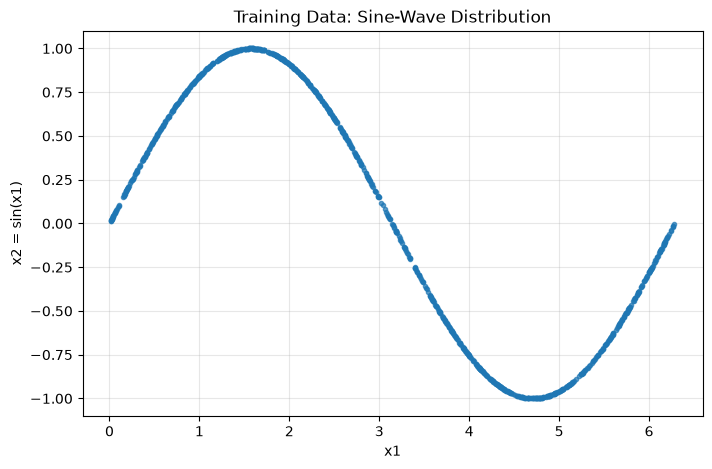

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(train_data[:, 0], train_data[:, 1], ".", alpha=0.7)
plt.title("Training Data: Sine-Wave Distribution")
plt.xlabel("x1")
plt.ylabel("x2 = sin(x1)")
plt.grid(True, alpha=0.3)
plt.show()

Create DataLoader

In [5]:
batch_size = 32

train_loader = DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True
)

print("Number of batches:", len(train_loader))

Number of batches: 32


Discriminator class (MLP)

In [6]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


discriminator = Discriminator().to(device)
discriminator

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=64, out_features=1, bias=True)
    (10): Sigmoid()
  )
)

Generator class (MLP)


In [7]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 2)  # output (x1, x2)-like pair
        )

    def forward(self, z):
        return self.model(z)


generator = Generator().to(device)
generator

Generator(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=2, bias=True)
  )
)

Loss function and optimizers

In [8]:
# Hyperparameters
lr = 0.001
num_epochs = 2000

loss_function = nn.BCELoss()

optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)

Training loop for sine-wave GAN

In [9]:
losses_discriminator = []
losses_generator = []

for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):
        real_samples = real_samples.to(device)

        # Labels for real and fake samples
        real_samples_labels = torch.ones((real_samples.size(0), 1), device=device)
        latent_space_samples = torch.randn((real_samples.size(0), 2), device=device)
        generated_samples = generator(latent_space_samples)
        generated_samples_labels = torch.zeros((real_samples.size(0), 1), device=device)

        # Concatenate real and fake samples and labels
        all_samples = torch.cat((real_samples, generated_samples), dim=0)
        all_samples_labels = torch.cat(
            (real_samples_labels, generated_samples_labels),
            dim=0
        )

        # Train Discriminator
        discriminator.zero_grad()
        output_discriminator = discriminator(all_samples)
        loss_discriminator = loss_function(output_discriminator, all_samples_labels)
        loss_discriminator.backward()
        optimizer_discriminator.step()

        # Train Generator
        latent_space_samples = torch.randn((real_samples.size(0), 2), device=device)
        generator.zero_grad()
        generated_samples = generator(latent_space_samples)
        output_discriminator_generated = discriminator(generated_samples)
        loss_generator = loss_function(
            output_discriminator_generated,
            real_samples_labels
        )
        loss_generator.backward()
        optimizer_generator.step()

    # Store losses for monitoring
    losses_discriminator.append(loss_discriminator.item())
    losses_generator.append(loss_generator.item())

    # Print progress every 100 epochs
    if epoch % 100 == 0:
        print(
            f"Epoch: {epoch:4d} | "
            f"Loss D: {loss_discriminator.item():.4f} | "
            f"Loss G: {loss_generator.item():.4f}"
        )

Epoch:    0 | Loss D: 0.1065 | Loss G: 2.6915
Epoch:  100 | Loss D: 0.6953 | Loss G: 0.6653
Epoch:  200 | Loss D: 0.6572 | Loss G: 0.7676
Epoch:  300 | Loss D: 0.6981 | Loss G: 0.7695
Epoch:  400 | Loss D: 0.4997 | Loss G: 1.1217
Epoch:  500 | Loss D: 0.6478 | Loss G: 0.8069
Epoch:  600 | Loss D: 0.6077 | Loss G: 0.9534
Epoch:  700 | Loss D: 0.6974 | Loss G: 0.7195
Epoch:  800 | Loss D: 0.5995 | Loss G: 0.9524
Epoch:  900 | Loss D: 0.6107 | Loss G: 0.7893
Epoch: 1000 | Loss D: 0.6843 | Loss G: 0.6975
Epoch: 1100 | Loss D: 0.6907 | Loss G: 0.7129
Epoch: 1200 | Loss D: 0.6361 | Loss G: 0.6764
Epoch: 1300 | Loss D: 0.6497 | Loss G: 0.7603
Epoch: 1400 | Loss D: 0.6244 | Loss G: 0.9542
Epoch: 1500 | Loss D: 0.6728 | Loss G: 0.7441
Epoch: 1600 | Loss D: 0.6817 | Loss G: 0.7250
Epoch: 1700 | Loss D: 0.6974 | Loss G: 0.8305
Epoch: 1800 | Loss D: 0.6524 | Loss G: 0.8093
Epoch: 1900 | Loss D: 0.5936 | Loss G: 0.8078


Visualize the losses

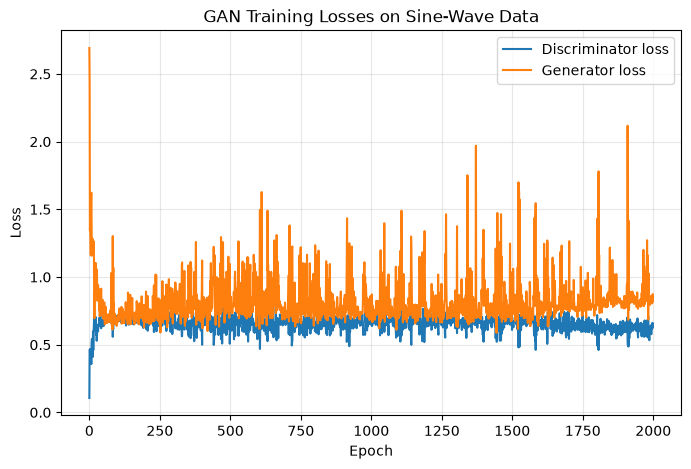

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(losses_discriminator, label="Discriminator loss")
plt.plot(losses_generator, label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses on Sine-Wave Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Generate and plot fake samples


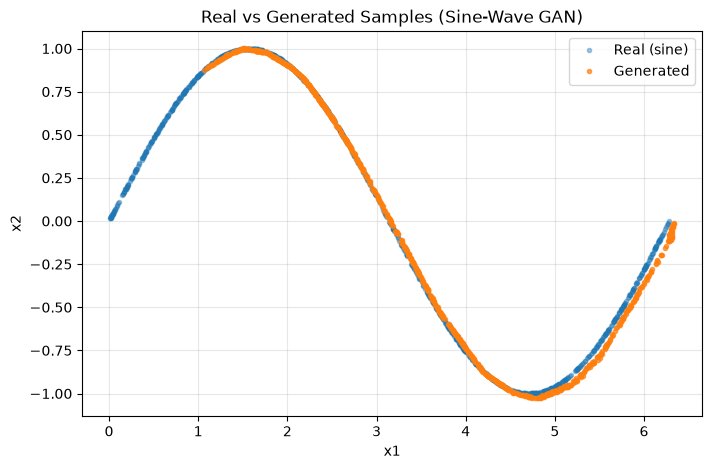

In [11]:
# Generate 1000 random latent points and map through generator
latent_space_samples = torch.randn(1000, 2, device=device)
generated_samples = generator(latent_space_samples)
generated_samples_np = generated_samples.detach().cpu().numpy()

plt.figure(figsize=(8, 5))
plt.plot(train_data[:, 0], train_data[:, 1], ".", alpha=0.4, label="Real (sine)")
plt.plot(
    generated_samples_np[:, 0],
    generated_samples_np[:, 1],
    ".",
    alpha=0.7,
    label="Generated"
)
plt.title("Real vs Generated Samples (Sine-Wave GAN)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Reflection on the sine-wave GAN

The GAN successfully learned the overall sine-wave structure from the synthetic 2D training data. The generated samples align closely with the real curve, suggesting that the generator captured the main nonlinear pattern.

The loss curves do not decrease smoothly, which is expected in GAN training because the generator and discriminator are trained in competition. After the initial epochs, both losses fluctuate within a bounded range, indicating a relatively stable adversarial training process rather than complete collapse.

A small mismatch remains near the boundary regions of the curve, which suggests the generator does not perfectly reproduce the full support of the data distribution. This can be improved later by modifying the architecture or tuning the learning process.

Visually, the generator matches the central high-variance region of the sine-wave well but shows slightly larger deviations near the start and end of the interval, where fewer training points are available and the function changes more rapidly.

# Part 1.2: GAN on a New 2D Distribution

In this section, the GAN is trained on a second synthetic 2D dataset.  
I use a mixture of Gaussians to test whether the generator can learn a multi-modal distribution rather than a single smooth curve.

Generate the mixture-of-Gaussians dataset

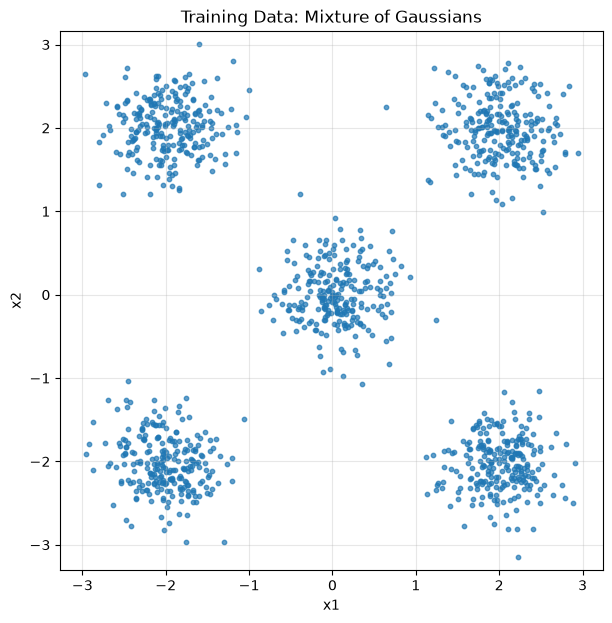

MoG data shape: torch.Size([1200, 2])
Number of batches: 38


In [12]:
def generate_mixture_of_gaussians(n_samples=1200):
    centers = torch.tensor([
        [-2.0, -2.0],
        [-2.0,  2.0],
        [ 2.0, -2.0],
        [ 2.0,  2.0],
        [ 0.0,  0.0]
    ], dtype=torch.float32)

    samples_per_cluster = n_samples // len(centers)
    all_samples = []

    for center in centers:
        cluster = center + 0.35 * torch.randn(samples_per_cluster, 2)
        all_samples.append(cluster)

    data = torch.cat(all_samples, dim=0)
    labels = torch.zeros(data.size(0))
    dataset = [(data[i], labels[i]) for i in range(data.size(0))]
    return data, dataset


mog_data, mog_dataset = generate_mixture_of_gaussians(n_samples=1200)

plt.figure(figsize=(7, 7))
plt.scatter(mog_data[:, 0], mog_data[:, 1], s=10, alpha=0.7)
plt.title("Training Data: Mixture of Gaussians")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.show()

mog_loader = DataLoader(mog_dataset, batch_size=32, shuffle=True)

print("MoG data shape:", mog_data.shape)
print("Number of batches:", len(mog_loader))

Reinitialize fresh models

In [13]:
discriminator_mog = Discriminator().to(device)
generator_mog = Generator().to(device)

optimizer_discriminator_mog = torch.optim.Adam(discriminator_mog.parameters(), lr=0.001)
optimizer_generator_mog = torch.optim.Adam(generator_mog.parameters(), lr=0.001)

loss_function = nn.BCELoss()

Train on the new dataset

In [14]:
losses_discriminator_mog = []
losses_generator_mog = []

num_epochs_mog = 2000

for epoch in range(num_epochs_mog):
    for real_samples, _ in mog_loader:
        real_samples = real_samples.to(device)

        real_labels = torch.ones((real_samples.size(0), 1), device=device)
        fake_labels = torch.zeros((real_samples.size(0), 1), device=device)

        # Train discriminator
        latent_space_samples = torch.randn((real_samples.size(0), 2), device=device)
        generated_samples = generator_mog(latent_space_samples)

        all_samples = torch.cat((real_samples, generated_samples), dim=0)
        all_labels = torch.cat((real_labels, fake_labels), dim=0)

        discriminator_mog.zero_grad()
        output_discriminator = discriminator_mog(all_samples)
        loss_discriminator = loss_function(output_discriminator, all_labels)
        loss_discriminator.backward()
        optimizer_discriminator_mog.step()

        # Train generator
        latent_space_samples = torch.randn((real_samples.size(0), 2), device=device)

        generator_mog.zero_grad()
        generated_samples = generator_mog(latent_space_samples)
        output_discriminator_generated = discriminator_mog(generated_samples)

        loss_generator = loss_function(output_discriminator_generated, real_labels)
        loss_generator.backward()
        optimizer_generator_mog.step()

    losses_discriminator_mog.append(loss_discriminator.item())
    losses_generator_mog.append(loss_generator.item())

    if epoch % 100 == 0:
        print(
            f"Epoch: {epoch:4d} | "
            f"Loss D: {loss_discriminator.item():.4f} | "
            f"Loss G: {loss_generator.item():.4f}"
        )

Epoch:    0 | Loss D: 0.3286 | Loss G: 1.9548
Epoch:  100 | Loss D: 0.5035 | Loss G: 1.1440
Epoch:  200 | Loss D: 0.6001 | Loss G: 1.3491
Epoch:  300 | Loss D: 0.5089 | Loss G: 0.9461
Epoch:  400 | Loss D: 0.5040 | Loss G: 0.9423
Epoch:  500 | Loss D: 0.5853 | Loss G: 0.9349
Epoch:  600 | Loss D: 0.6450 | Loss G: 0.9746
Epoch:  700 | Loss D: 0.4391 | Loss G: 1.2377
Epoch:  800 | Loss D: 0.5815 | Loss G: 1.1796
Epoch:  900 | Loss D: 0.5688 | Loss G: 0.9229
Epoch: 1000 | Loss D: 0.5818 | Loss G: 0.9791
Epoch: 1100 | Loss D: 0.4987 | Loss G: 0.9602
Epoch: 1200 | Loss D: 0.5884 | Loss G: 0.9769
Epoch: 1300 | Loss D: 0.6052 | Loss G: 1.0116
Epoch: 1400 | Loss D: 0.5553 | Loss G: 0.9329
Epoch: 1500 | Loss D: 0.5279 | Loss G: 0.9525
Epoch: 1600 | Loss D: 0.5098 | Loss G: 1.3827
Epoch: 1700 | Loss D: 0.3511 | Loss G: 1.2781
Epoch: 1800 | Loss D: 0.4749 | Loss G: 0.9932
Epoch: 1900 | Loss D: 0.5635 | Loss G: 1.0804


Plot losses and generated samples

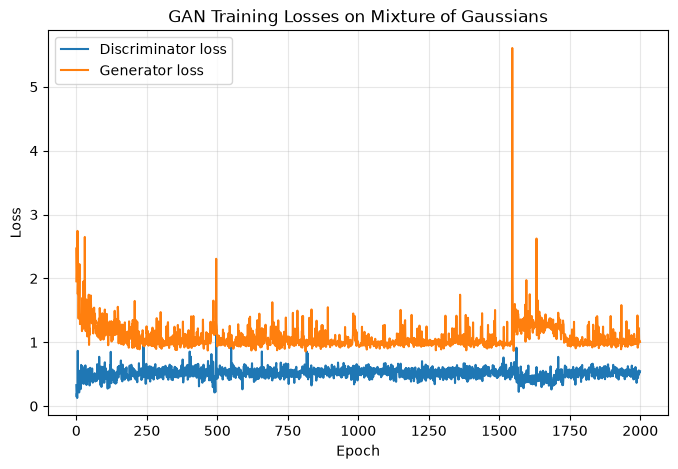

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(losses_discriminator_mog, label="Discriminator loss")
plt.plot(losses_generator_mog, label="Generator loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses on Mixture of Gaussians")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

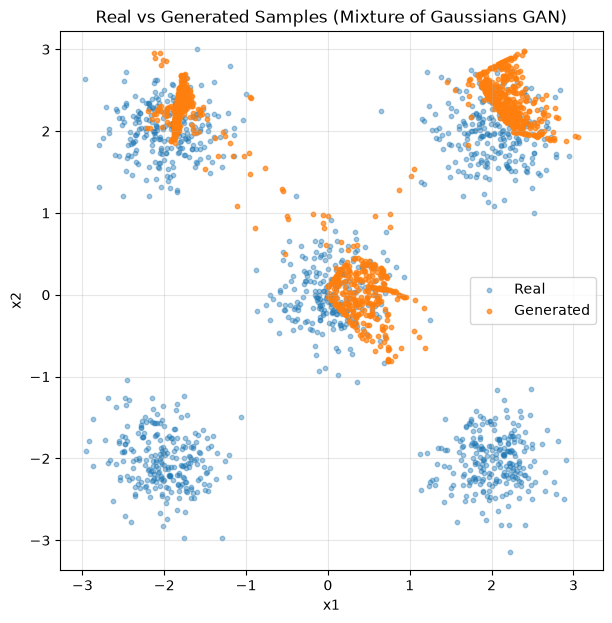

In [16]:
latent_space_samples = torch.randn(1200, 2, device=device)
generated_mog = generator_mog(latent_space_samples).detach().cpu()

plt.figure(figsize=(7, 7))
plt.scatter(mog_data[:, 0], mog_data[:, 1], s=10, alpha=0.4, label="Real")
plt.scatter(generated_mog[:, 0], generated_mog[:, 1], s=10, alpha=0.7, label="Generated")
plt.title("Real vs Generated Samples (Mixture of Gaussians GAN)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.show()

## Reflection on the mixture-of-Gaussians GAN

The GAN successfully locates the main cluster centres of the mixture-of-Gaussians dataset and places generated samples close to the real modes, especially around the central cluster and the upper-right cluster. This shows that the generator can learn a multi-modal distribution rather than collapsing entirely to a single region.

However, the generated clusters tend to be more elongated than the real Gaussian blobs and sometimes show trailing points between clusters, indicating imperfect modelling of the underlying covariance structure. The generator is covering the right areas but not fully matching the precise shape and spread of each Gaussian.

The loss curves remain noisy but bounded, with occasional generator loss spikes. This is consistent with adversarial training for multi-modal data, where the generator continuously adjusts to local weaknesses detected by the discriminator. In later sections, architectural changes or alternative loss formulations could help stabilise training and improve mode coverage further.

The generator therefore covers all true modes but with distorted shapes, which is a common outcome for simple GAN architectures on multi-modal toy data.

# Part 1.3: Architecture modification and comparison

In this section, I modify the original GAN architecture by:
- using LeakyReLU instead of ReLU in the discriminator, to reduce the risk of dead neurons,
- increasing the depth and width of the generator network.

The modified GAN is trained on the same mixture-of-Gaussians dataset as before, and its generated samples are visually compared against the original model outputs.

Define modified architectures

In [17]:
class DiscriminatorWide(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


class GeneratorDeep(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, z):
        return self.model(z)


disc_mod = DiscriminatorWide().to(device)
gen_mod = GeneratorDeep().to(device)

disc_mod, gen_mod

(DiscriminatorWide(
   (model): Sequential(
     (0): Linear(in_features=2, out_features=256, bias=True)
     (1): LeakyReLU(negative_slope=0.2)
     (2): Dropout(p=0.3, inplace=False)
     (3): Linear(in_features=256, out_features=256, bias=True)
     (4): LeakyReLU(negative_slope=0.2)
     (5): Dropout(p=0.3, inplace=False)
     (6): Linear(in_features=256, out_features=128, bias=True)
     (7): LeakyReLU(negative_slope=0.2)
     (8): Dropout(p=0.3, inplace=False)
     (9): Linear(in_features=128, out_features=1, bias=True)
     (10): Sigmoid()
   )
 ),
 GeneratorDeep(
   (model): Sequential(
     (0): Linear(in_features=2, out_features=32, bias=True)
     (1): ReLU()
     (2): Linear(in_features=32, out_features=64, bias=True)
     (3): ReLU()
     (4): Linear(in_features=64, out_features=64, bias=True)
     (5): ReLU()
     (6): Linear(in_features=64, out_features=32, bias=True)
     (7): ReLU()
     (8): Linear(in_features=32, out_features=2, bias=True)
   )
 ))

Set up loss and optimizers

In [18]:
lr_mod = 0.001
num_epochs_mod = 2000

loss_fn_mod = nn.BCELoss()

opt_disc_mod = torch.optim.Adam(disc_mod.parameters(), lr=lr_mod)
opt_gen_mod = torch.optim.Adam(gen_mod.parameters(), lr=lr_mod)

Train the modified GAN on MoG

In [19]:
losses_disc_mod = []
losses_gen_mod = []

for epoch in range(num_epochs_mod):
    for real_samples, _ in mog_loader:
        real_samples = real_samples.to(device)

        real_labels = torch.ones((real_samples.size(0), 1), device=device)
        fake_labels = torch.zeros((real_samples.size(0), 1), device=device)

        # Train modified discriminator
        latent = torch.randn((real_samples.size(0), 2), device=device)
        fake_samples = gen_mod(latent)

        all_samples = torch.cat((real_samples, fake_samples), dim=0)
        all_labels = torch.cat((real_labels, fake_labels), dim=0)

        disc_mod.zero_grad()
        disc_outputs = disc_mod(all_samples)
        loss_disc = loss_fn_mod(disc_outputs, all_labels)
        loss_disc.backward()
        opt_disc_mod.step()

        # Train modified generator
        latent = torch.randn((real_samples.size(0), 2), device=device)
        gen_mod.zero_grad()
        fake_samples = gen_mod(latent)
        disc_outputs_fake = disc_mod(fake_samples)

        loss_gen = loss_fn_mod(disc_outputs_fake, real_labels)
        loss_gen.backward()
        opt_gen_mod.step()

    losses_disc_mod.append(loss_disc.item())
    losses_gen_mod.append(loss_gen.item())

    if epoch % 100 == 0:
        print(
            f"[Modified] Epoch: {epoch:4d} | "
            f"Loss D: {loss_disc.item():.4f} | "
            f"Loss G: {loss_gen.item():.4f}"
        )

[Modified] Epoch:    0 | Loss D: 0.3575 | Loss G: 3.1462
[Modified] Epoch:  100 | Loss D: 0.6713 | Loss G: 0.8904
[Modified] Epoch:  200 | Loss D: 0.4913 | Loss G: 1.1901
[Modified] Epoch:  300 | Loss D: 0.7465 | Loss G: 0.6536
[Modified] Epoch:  400 | Loss D: 0.6774 | Loss G: 0.7152
[Modified] Epoch:  500 | Loss D: 0.7009 | Loss G: 0.7126
[Modified] Epoch:  600 | Loss D: 0.5850 | Loss G: 0.9849
[Modified] Epoch:  700 | Loss D: 0.6843 | Loss G: 0.7530
[Modified] Epoch:  800 | Loss D: 0.5781 | Loss G: 0.6738
[Modified] Epoch:  900 | Loss D: 0.6903 | Loss G: 0.6739
[Modified] Epoch: 1000 | Loss D: 0.6977 | Loss G: 0.7319
[Modified] Epoch: 1100 | Loss D: 0.7258 | Loss G: 0.7168
[Modified] Epoch: 1200 | Loss D: 0.7041 | Loss G: 0.6962
[Modified] Epoch: 1300 | Loss D: 0.6946 | Loss G: 0.7001
[Modified] Epoch: 1400 | Loss D: 0.7042 | Loss G: 0.7070
[Modified] Epoch: 1500 | Loss D: 0.7706 | Loss G: 0.6340
[Modified] Epoch: 1600 | Loss D: 0.7251 | Loss G: 0.6950
[Modified] Epoch: 1700 | Loss D

Plot losses for the modified model

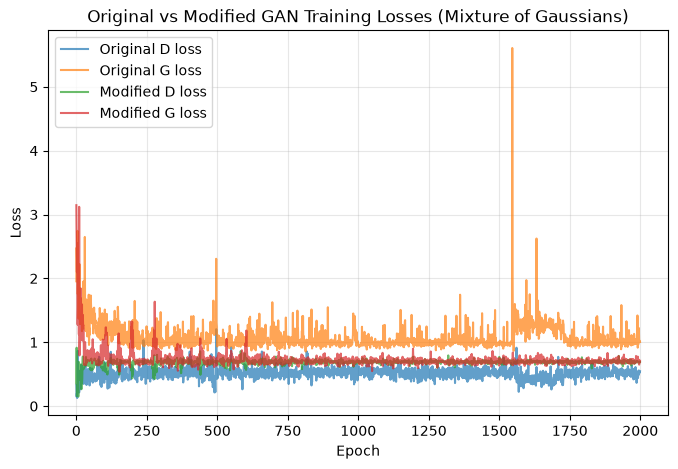

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(losses_discriminator_mog, label="Original D loss", alpha=0.7)
plt.plot(losses_generator_mog, label="Original G loss", alpha=0.7)
plt.plot(losses_disc_mod, label="Modified D loss", alpha=0.7)
plt.plot(losses_gen_mod, label="Modified G loss", alpha=0.7)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Original vs Modified GAN Training Losses (Mixture of Gaussians)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Compare generated samples side by side

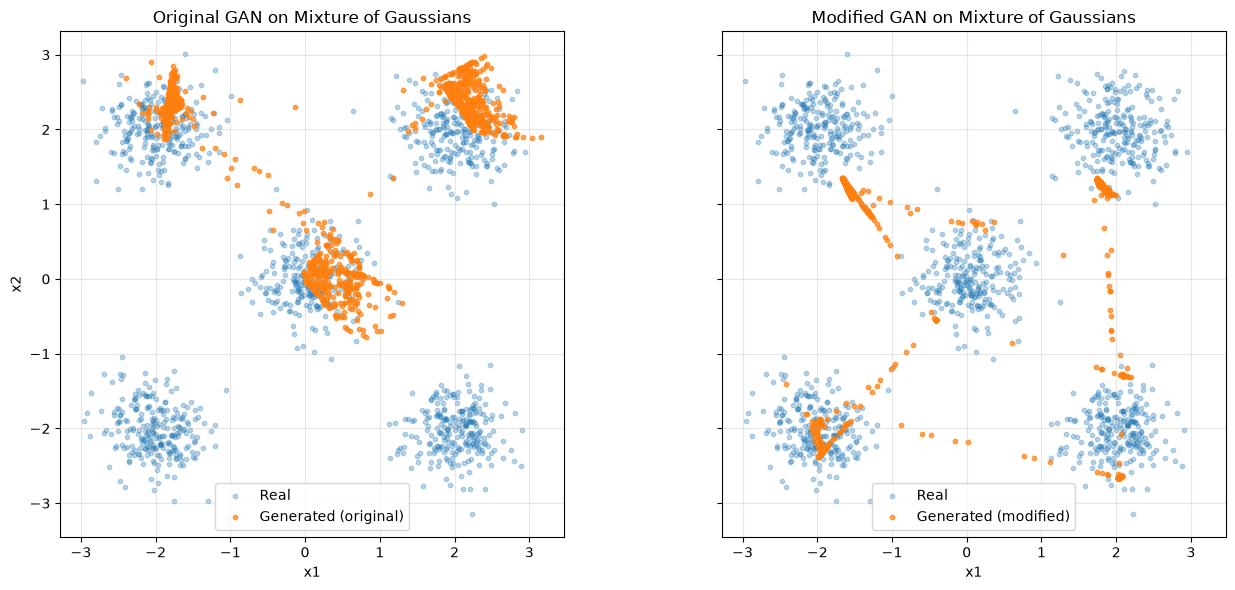

In [21]:
# Generate samples from original and modified generators
latent = torch.randn(1200, 2, device=device)
gen_mog_original = generator_mog(latent).detach().cpu()
gen_mog_modified = gen_mod(latent).detach().cpu()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

axes[0].scatter(mog_data[:, 0], mog_data[:, 1], s=10, alpha=0.3, label="Real")
axes[0].scatter(gen_mog_original[:, 0], gen_mog_original[:, 1], s=10, alpha=0.7, label="Generated (original)")
axes[0].set_title("Original GAN on Mixture of Gaussians")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect("equal", adjustable="box")

axes[1].scatter(mog_data[:, 0], mog_data[:, 1], s=10, alpha=0.3, label="Real")
axes[1].scatter(gen_mog_modified[:, 0], gen_mog_modified[:, 1], s=10, alpha=0.7, label="Generated (modified)")
axes[1].set_title("Modified GAN on Mixture of Gaussians")
axes[1].set_xlabel("x1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

## Comparison of original vs modified architectures (Mixture-of-Gaussians)

Both the original and modified GANs learn the overall layout of the five Gaussian clusters, but they exhibit different failure modes. The original architecture tends to produce stretched, wedge-shaped blobs inside some clusters, while the modified architecture generates more linear chains of points between cluster centres, forming approximate paths rather than compact Gaussian blobs, indicating that both models cover the right regions but distort the underlying Gaussian shapes.

Looking at the loss curves, the modified discriminator and generator losses settle into a narrower band and show fewer large spikes than the original model, which suggests slightly more stable adversarial dynamics. However, the visual samples show that architectural changes alone do not fully resolve mode-shape distortions: the generator still struggles to reproduce the true isotropic Gaussian structure. This highlights that even on simple synthetic data, GAN behaviour is sensitive to architectural choices and requires careful tuning and evaluation beyond loss values.